Importing Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


Loading Dataset

In [4]:
(X_train , y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [5]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


Visualizing Data

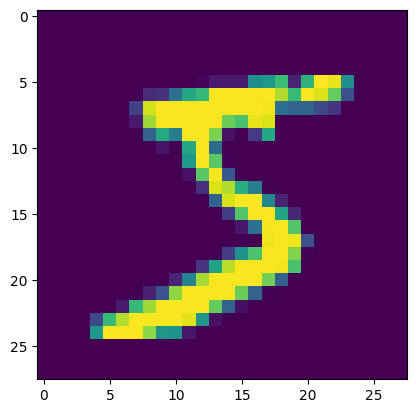

5


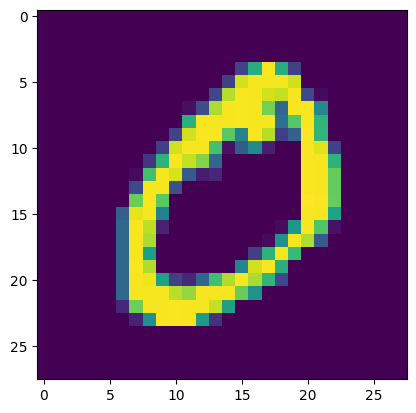

0


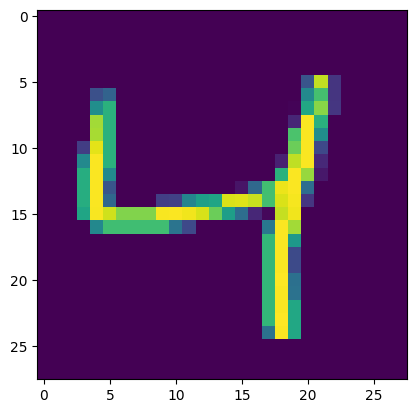

4


In [6]:
for i in range(3):
    plt.imshow(X_train[i])
    plt.show()
    print(y_train[i])

In [7]:
print(X_train.min())
print(X_train.max())

0
255


Normalizing Data

In [8]:
X_train = X_train /255
X_test = X_test / 255

print(X_train.min())
print(X_train.max())

0.0
1.0


Flattening Data

In [9]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


Converting Labels into vectors

In [10]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(y_train.shape)
print(y_test.shape)

for i in range(3):
    print(y_train[i])

(60000, 10)
(10000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


Model Building(Baseline ANN)

In [11]:
model = keras.Sequential()

In [12]:
model.add(keras.Input(shape=(784,)))
model.add(keras.layers.Dense(128, activation='relu'))

In [13]:
model.add(keras.layers.Dense(10, activation='softmax'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [16]:
history =model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9168 - loss: 0.2879 - val_accuracy: 0.9558 - val_loss: 0.1521
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9617 - loss: 0.1287 - val_accuracy: 0.9611 - val_loss: 0.1300
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9741 - loss: 0.0869 - val_accuracy: 0.9685 - val_loss: 0.1025
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9802 - loss: 0.0652 - val_accuracy: 0.9728 - val_loss: 0.0888
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9848 - loss: 0.0507 - val_accuracy: 0.9735 - val_loss: 0.0861
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9884 - loss: 0.0387 - val_accuracy: 0.9733 - val_loss: 0.0886
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.9751 - val_loss: 0.0887
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9924 - loss: 0.0252 - 

Plotting train vs validation curve

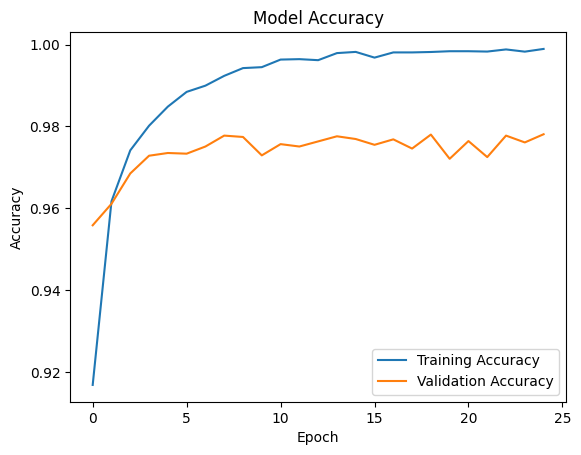

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

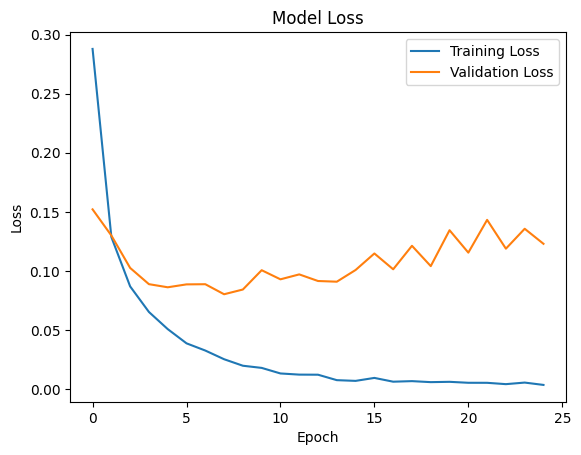

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [19]:
test_loss , test_accuracy = model.evaluate(X_test, y_test)

print("Test accuracy:",test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9805 - loss: 0.1035
Test accuracy: 0.9804999828338623
Test loss: 0.10351280868053436


Confusion matrix

In [20]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1) #Convert probabilities to digits

y_true = np.argmax(y_test, axis=1) #Converting encoded test labels into digits

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

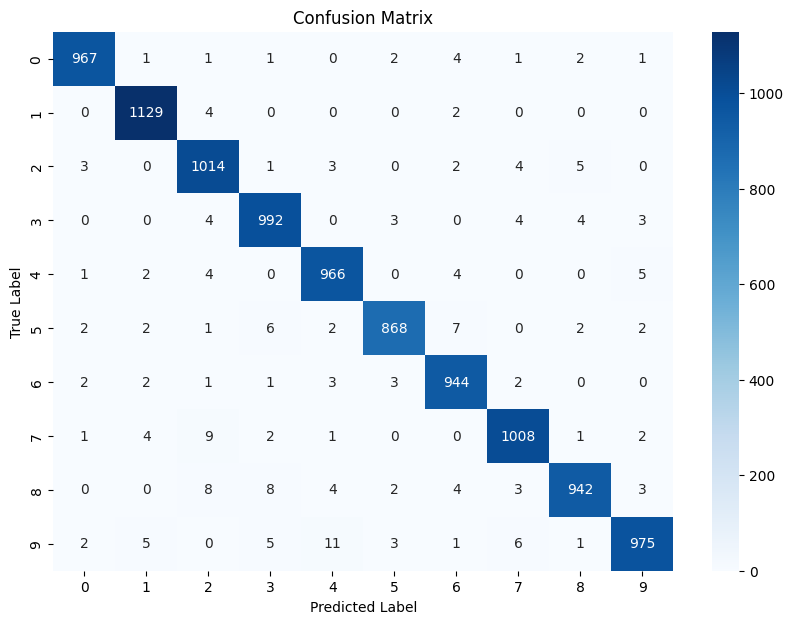

In [22]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: { accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9805
Precision: 0.9805
Recall: 0.9805
F1 Score: 0.9805


Building Model (Adding extra hidden layer)

In [46]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

model2 = keras.Sequential()

model2.add(keras.Input(shape=(784,)))
model2.add(keras.layers.Dense(128, activation='relu'))
model2.add(Dropout(0.3))
model2.add(keras.layers.Dense(64, activation='relu'))
model2.add(keras.layers.Dense(10, activation='softmax'))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model2.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stop])


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8993 - loss: 0.3383 - val_accuracy: 0.9571 - val_loss: 0.1463
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9485 - loss: 0.1688 - val_accuracy: 0.9659 - val_loss: 0.1146
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9594 - loss: 0.1325 - val_accuracy: 0.9708 - val_loss: 0.0956
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9640 - loss: 0.1168 - val_accuracy: 0.9722 - val_loss: 0.0942
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9685 - loss: 0.0997 - val_accuracy: 0.9748 - val_loss: 0.0854
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9718 - loss: 0.0903 - val_accuracy: 0.9747 - val_loss: 0.0864
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9734 - loss: 0.0845 - val_accuracy: 0.9731 - val_loss: 0.0960
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9747 - loss: 0.0787 - 

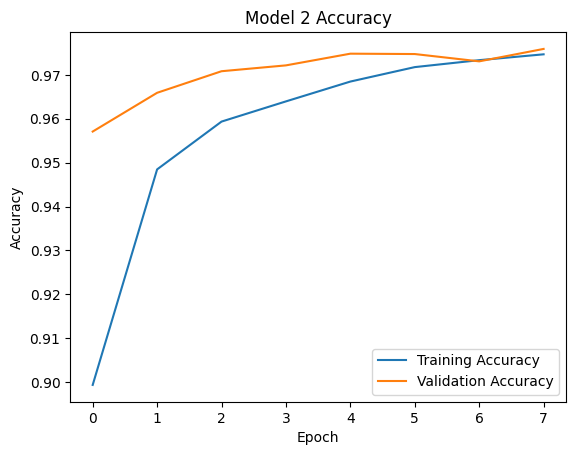

In [48]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title("Model 2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

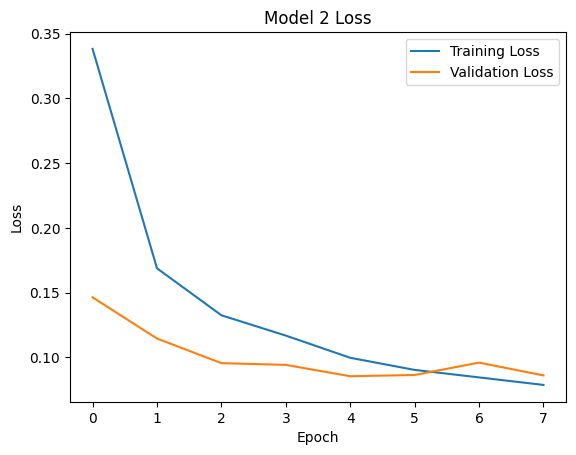

In [49]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

plt.title("Model 2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [60]:
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy2)
print("Test Loss:", test_loss2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9765 - loss: 0.0776
Test Accuracy: 0.9764999747276306
Test Loss: 0.07762426882982254


In [61]:
y_pred2 = model2.predict(X_test)
y_pred2 = np.argmax(y_pred2, axis=1)

y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


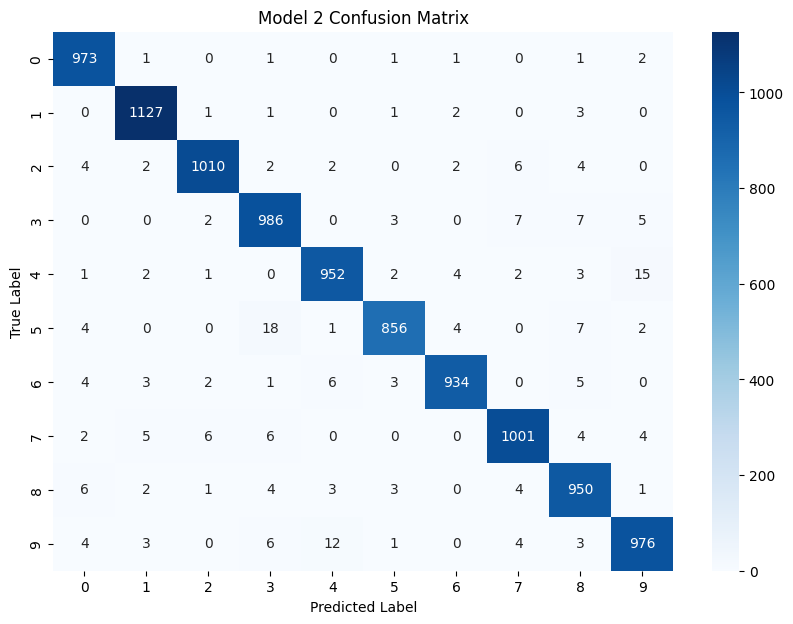

In [62]:
cm2 = confusion_matrix(y_true, y_pred2)

plt.figure(figsize=(10,7))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Model 2 Confusion Matrix")

plt.show()

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred2)
precision = precision_score(y_true, y_pred2, average='weighted')
recall = recall_score(y_true, y_pred2, average='weighted')
f1 = f1_score(y_true, y_pred2, average='weighted')

print(f"Accuracy: { accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9765
Precision: 0.9766
Recall: 0.9765
F1 Score: 0.9765


In [64]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ANN Model 1", "ANN Model 2"],
    "Architecture": ["784 -> 128 -> 10", "784 -> 128 -> Dropout-> 64 -> 10"],
    "Parameters": [101770, 109386],
    "Test Accuracy": [test_accuracy, test_accuracy2],
    "Test Loss": [test_loss, test_loss2]
})

comparison

,Model,Architecture,Parameters,Test Accuracy,Test Loss
0,ANN Model 1,784 -> 128 -> 10,101770,0.9805,0.103513
1,ANN Model 2,784 -> 128 -> Dropout-> 64 -> 10,109386,0.9765,0.077624
